In [1]:
!pip install openpyxl

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson

In [25]:

# =============================================================================
# 1. DATA LOADING AND PREPARATION (Ref. Section 5.5)
# =============================================================================
file_path = 'Zeri_Tommaso.xlsx'
df = pd.read_excel(file_path, sheet_name='Ex.3')

# Date Handling: Format 1973M01 -> %YM%m
date_col = df.columns[0]
try:
    df[date_col] = pd.to_datetime(df[date_col].astype(str), format='%YM%m')
    df.set_index(date_col, inplace=True)
    # Impostiamo la frequenza se possibile (MS = Month Start)
    if pd.infer_freq(df.index) is None:
        df.index.freq = 'MS'
    print(">>> Dates loaded successfully with format YYYYMmm")
except Exception as e:
    print(f">>> Error loading dates: {e}")

# Variable selection: Oil, Inf, Growth
data = df.iloc[:, -3:].copy()
data.columns = ['Oil', 'Inf', 'Growth']
data = data.dropna()

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS (Yt)")
print("="*60)
print(data.describe())


>>> Dates loaded successfully with format YYYYMmm

DESCRIPTIVE STATISTICS (Yt)
              Oil         Inf      Growth
count  400.000000  400.000000  400.000000
mean     0.048330    0.082833   -0.010197
std      0.558523    0.568821    0.508830
min     -1.439486   -1.849992   -1.433769
25%     -0.335722   -0.296170   -0.328022
50%      0.069378    0.072954   -0.008175
75%      0.416626    0.446823    0.350199
max      1.940120    2.296259    1.413135


In [26]:
# =============================================================================
# 2. LAG SELECTION (AIC, HQIC, BIC - Ref. Table 5.3)
# =============================================================================
model = VAR(data)
max_lags = 12
select = model.select_order(maxlags=max_lags)

print("\n" + "="*60)
print("LAG SELECTION CRITERIA (Information Criteria)")
print("="*60)
print(select.summary())

best_p = select.aic
print(f"\nOptimal Lag selected (AIC): {best_p}")



LAG SELECTION CRITERIA (Information Criteria)
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -3.970      -3.939     0.01887      -3.958
1      -5.124*     -5.002*   0.005951*     -5.076*
2       -5.091      -4.876    0.006154      -5.006
3       -5.064      -4.757    0.006322      -4.942
4       -5.033      -4.635    0.006518      -4.875
5       -5.024      -4.534    0.006577      -4.830
6       -4.998      -4.416    0.006753      -4.767
7       -4.978      -4.304    0.006894      -4.710
8       -4.957      -4.191    0.007037      -4.654
9       -4.937      -4.080    0.007179      -4.597
10      -4.900      -3.950    0.007456      -4.523
11      -4.889      -3.848    0.007539      -4.476
12      -4.867      -3.734    0.007708      -4.418
--------------------------------------------------

Optimal Lag selected (AIC): 1


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [27]:
# =============================================================================
# 3. VAR ESTIMATION (Ref. Def 5.1 and Eq. 5.1)
# =============================================================================
results = model.fit(best_p)

print("\n" + "="*60)
print("VAR(P) ESTIMATION OUTPUT")
print("="*60)
print(results.summary())



VAR(P) ESTIMATION OUTPUT
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 26, Jan, 2026
Time:                     14:04:53
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -5.01348
Nobs:                     399.000    HQIC:                  -5.08594
Log likelihood:          -662.346    FPE:                 0.00589619
AIC:                     -5.13345    Det(Omega_mle):      0.00572236
--------------------------------------------------------------------
Results for equation Oil
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.013185         0.022328            0.591           0.555
L1.Oil            0.523863         0.047872           10.943           0.000
L1.Inf            0.133575         0.047108         

In [28]:
# =============================================================================
# 4. STABILITY CHECK (Ref. Section 5.1.2.1)
# =============================================================================
print("\n" + "="*60)
print("STABILITY TEST (Eigenvalue Condition)")
print("="*60)
roots = results.roots
moduli = np.abs(roots)
print(f"Moduli of roots: {moduli}")
if results.is_stable():
    print("Result: The system is COVARIANCE STATIONARY (Stable).")
else:
    print("ATTENTION: The system is not stable.")


STABILITY TEST (Eigenvalue Condition)
Moduli of roots: [4.00082545 1.83347545 1.45834652]
Result: The system is COVARIANCE STATIONARY (Stable).


In [29]:
# =============================================================================
# 5. RESIDUAL DIAGNOSTICS (Def 5.2 - Vector White Noise)
# =============================================================================
print("\n" + "="*60)
print("DIAGNOSTICS: DURBIN-WATSON TEST")
print("="*60)
dw = durbin_watson(results.resid)
for col, val in zip(data.columns, dw):
    print(f"DW statistic for {col}: {val:.4f} (Target ~ 2.0)")


DIAGNOSTICS: DURBIN-WATSON TEST
DW statistic for Oil: 1.9298 (Target ~ 2.0)
DW statistic for Inf: 1.9974 (Target ~ 2.0)
DW statistic for Growth: 1.9525 (Target ~ 2.0)



--- Generating Separate IRF Plots for ALL Variables ---


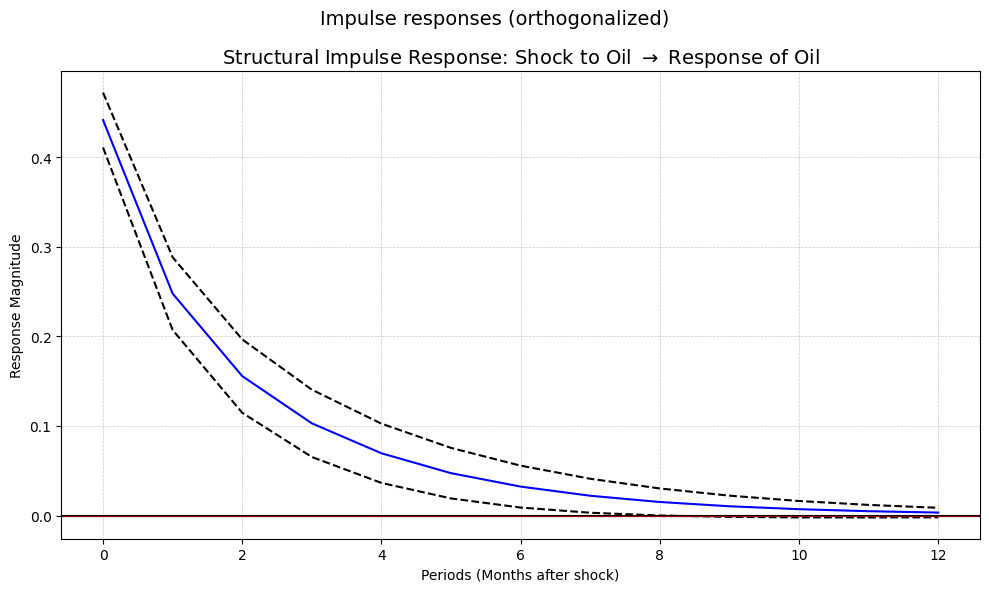

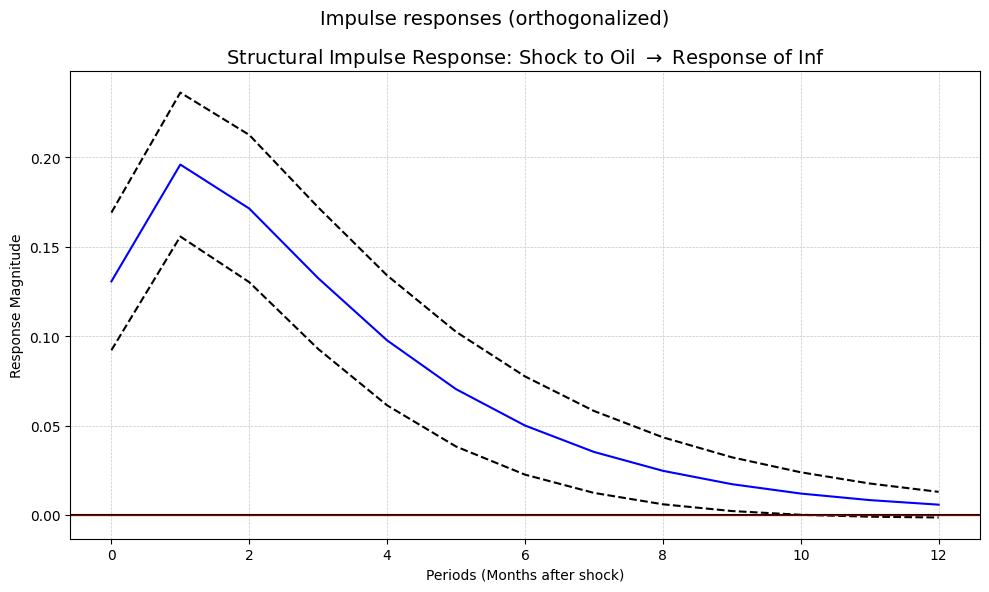

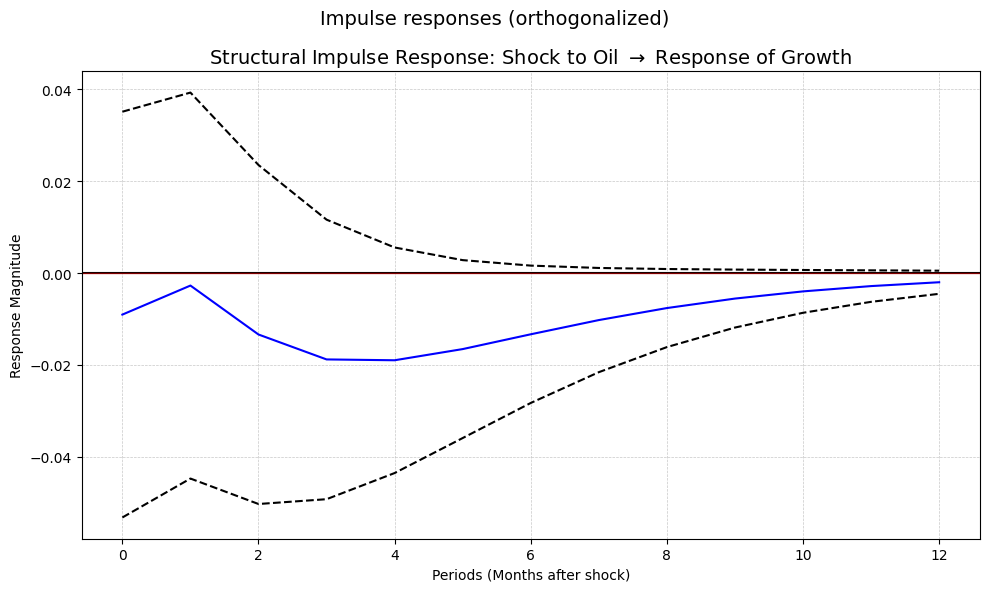

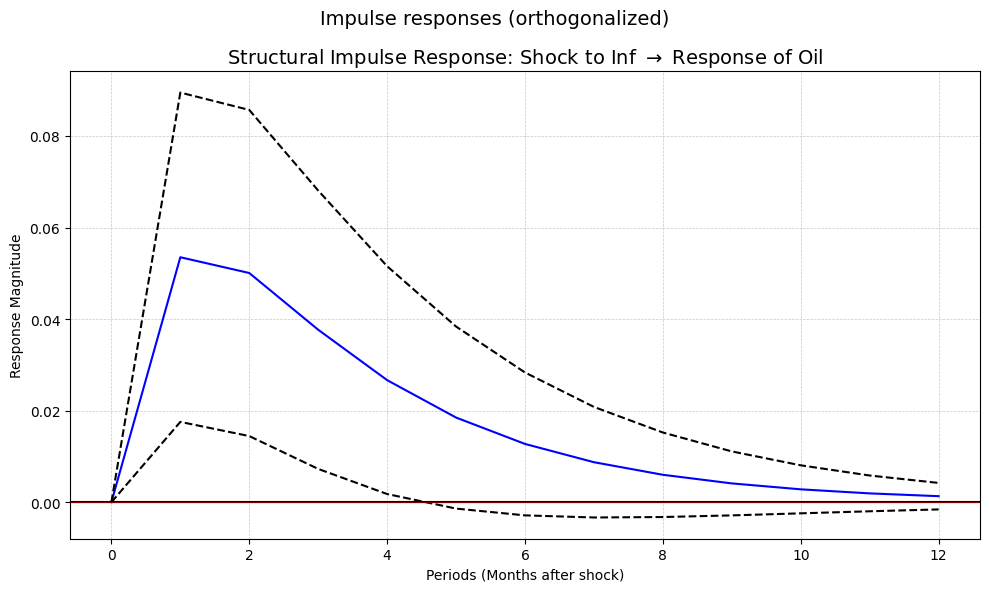

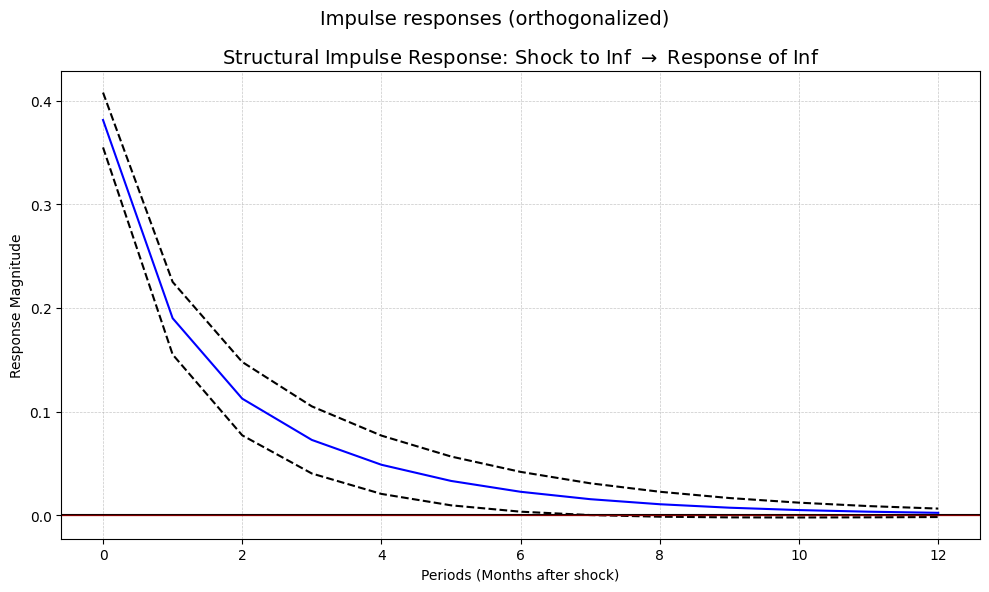

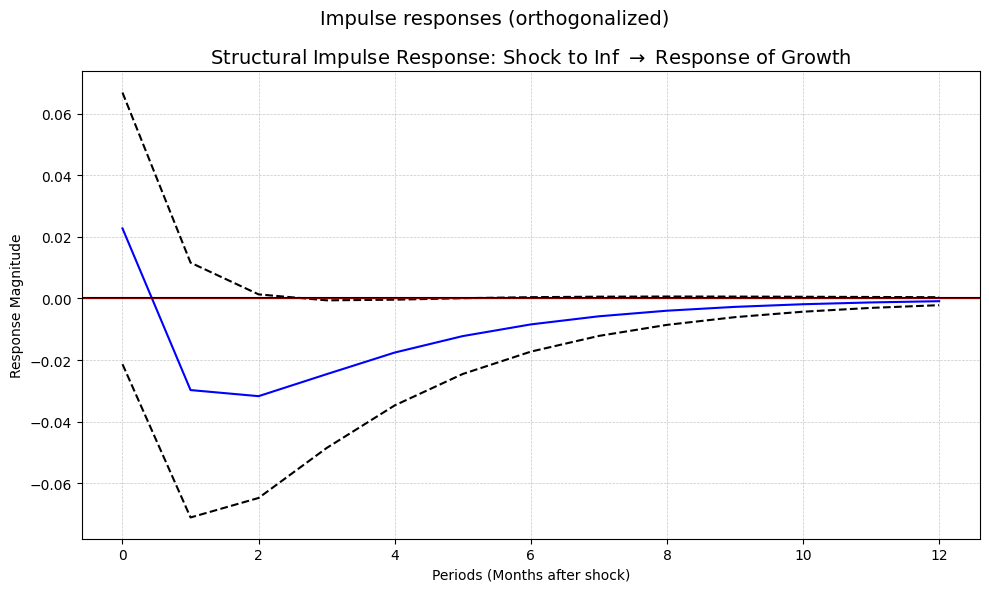

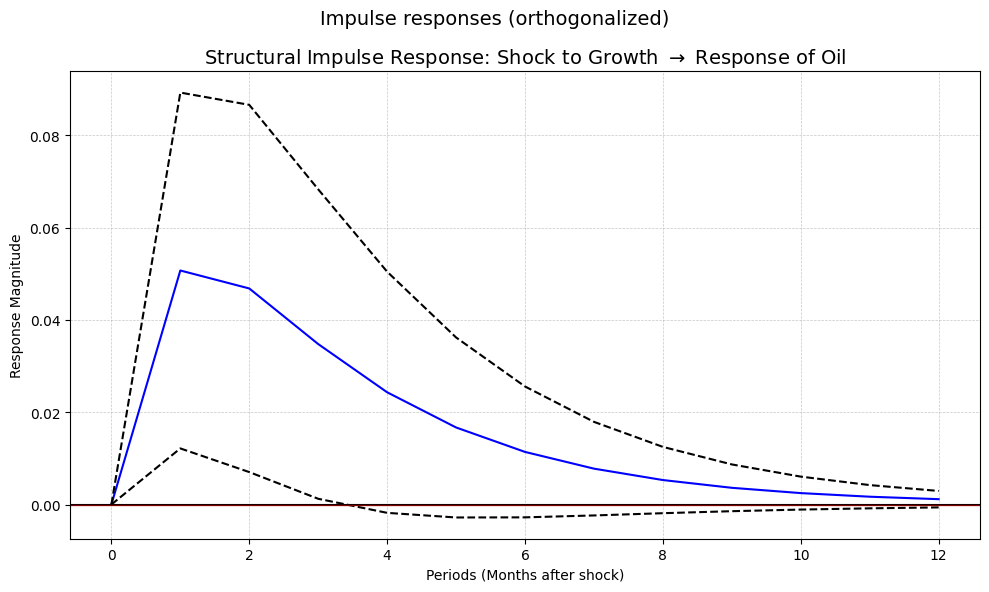

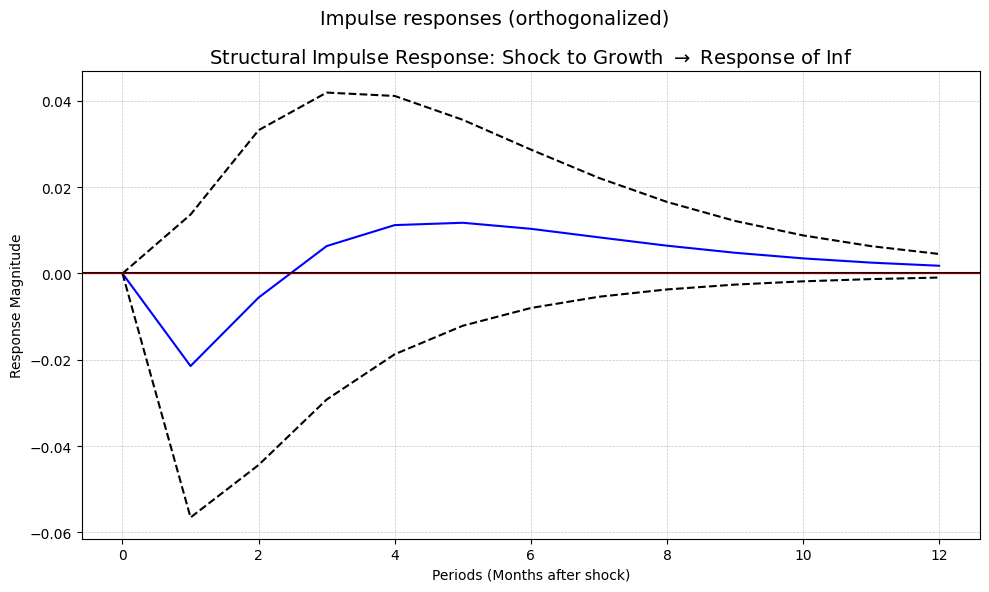

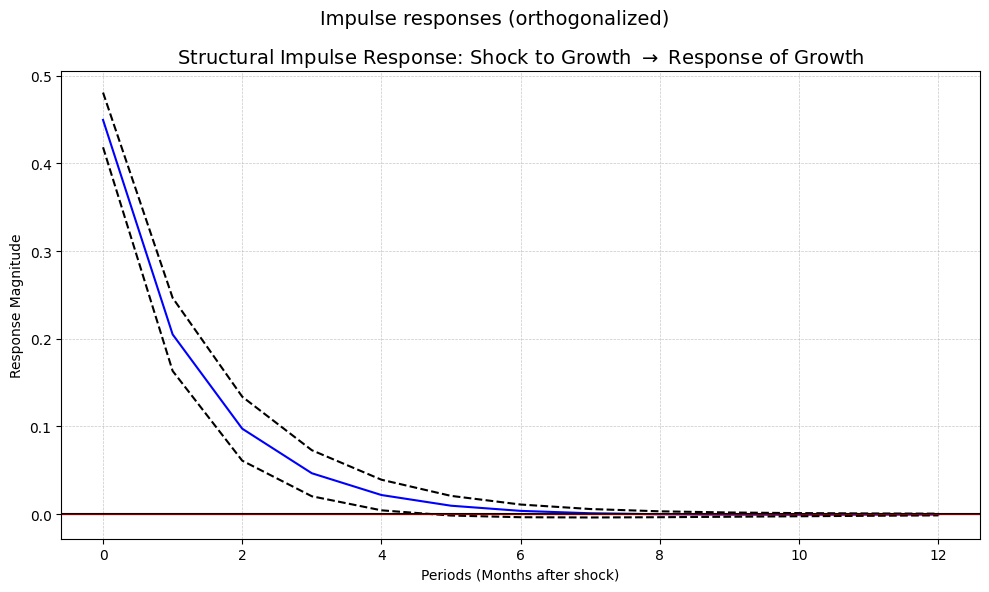

In [30]:
# =============================================================================
# 6. STRUCTURAL IRF - SEPARATE PLOTS FOR ALL VARIABLES
# =============================================================================
print("\n--- Generating Separate IRF Plots for ALL Variables ---")
irf = results.irf(12)
variable_names = data.columns

# Nested loop to generate 9 plots (every combination of Impulse -> Response)
for impulse in variable_names:
    for response in variable_names:
        fig = irf.plot(orth=True, impulse=impulse, response=response, figsize=(10, 6))

        # Customization in English
        plt.title(f'Structural Impulse Response: Shock to {impulse} $\\to$ Response of {response}', fontsize=14)
        plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.5)
        plt.xlabel("Periods (Months after shock)")
        plt.ylabel("Response Magnitude")
        plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)

        plt.tight_layout()
        plt.show()



VARIANCE DECOMPOSITION (FEVD - 10 Periods)
FEVD for Oil
          Oil       Inf    Growth
0    1.000000  0.000000  0.000000
1    0.979218  0.010950  0.009832
2    0.965108  0.018492  0.016400
3    0.957971  0.022362  0.019667
4    0.954597  0.024216  0.021187
5    0.953026  0.025089  0.021885
6    0.952296  0.025499  0.022205
7    0.951956  0.025691  0.022353
8    0.951797  0.025782  0.022422
9    0.951722  0.025824  0.022453

FEVD for Inf
          Oil       Inf    Growth
0    0.105023  0.894977  0.000000
1    0.233630  0.764433  0.001937
2    0.303558  0.694684  0.001757
3    0.338605  0.659637  0.001758
4    0.355960  0.641949  0.002090
5    0.364524  0.632995  0.002481
6    0.368731  0.628481  0.002788
7    0.370786  0.626224  0.002990
8    0.371784  0.625106  0.003110
9    0.372266  0.624557  0.003177

FEVD for Growth
          Oil       Inf    Growth
0    0.000403  0.002560  0.997037
1    0.000362  0.005720  0.993917
2    0.001045  0.009414  0.989541
3    0.002394  0.011633  0.9

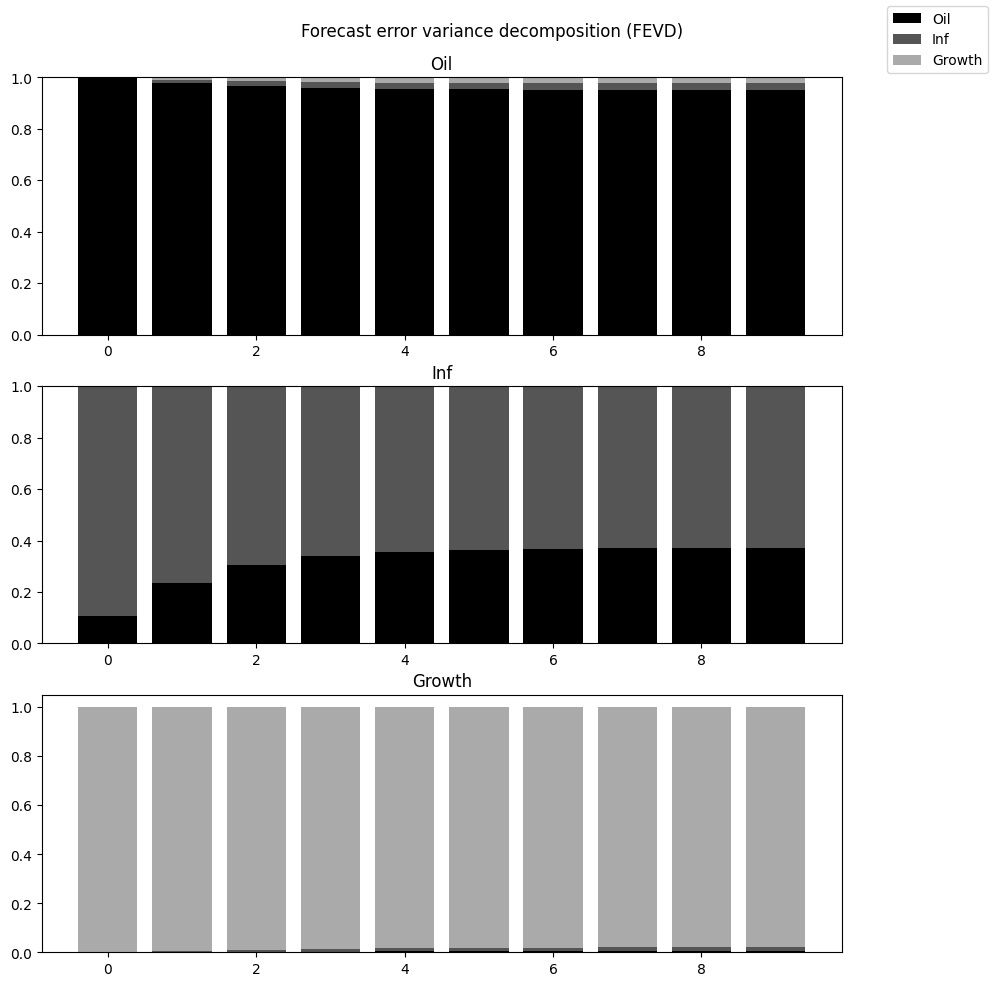

In [31]:
# =============================================================================
# 7. VARIANCE DECOMPOSITION (FEVD)
# =============================================================================
print("\n" + "="*60)
print("VARIANCE DECOMPOSITION (FEVD - 10 Periods)")
print("="*60)
fevd = results.fevd(10)
print(fevd.summary())
fevd.plot()
plt.show()


VAR FORECASTING (Dynamic h-step ahead)
Forecasts for the next 12 months:
                 Oil       Inf    Growth
2006-05-01  0.035270  0.060890 -0.112846
2006-06-01  0.027067  0.073033 -0.055413
2006-07-01  0.030870  0.073962 -0.030791
2006-08-01  0.035763  0.074373 -0.019533
2006-09-01  0.039652  0.075485 -0.014276
2006-10-01  0.042430  0.076938 -0.011863
2006-11-01  0.044352  0.078370 -0.010820
2006-12-01  0.045667  0.079605 -0.010430
2007-01-01  0.046566  0.080593 -0.010337
2007-02-01  0.047179  0.081349 -0.010367
2007-03-01  0.047597  0.081910 -0.010440
2007-04-01  0.047884  0.082319 -0.010518

--- Generating Forecast Plots ---


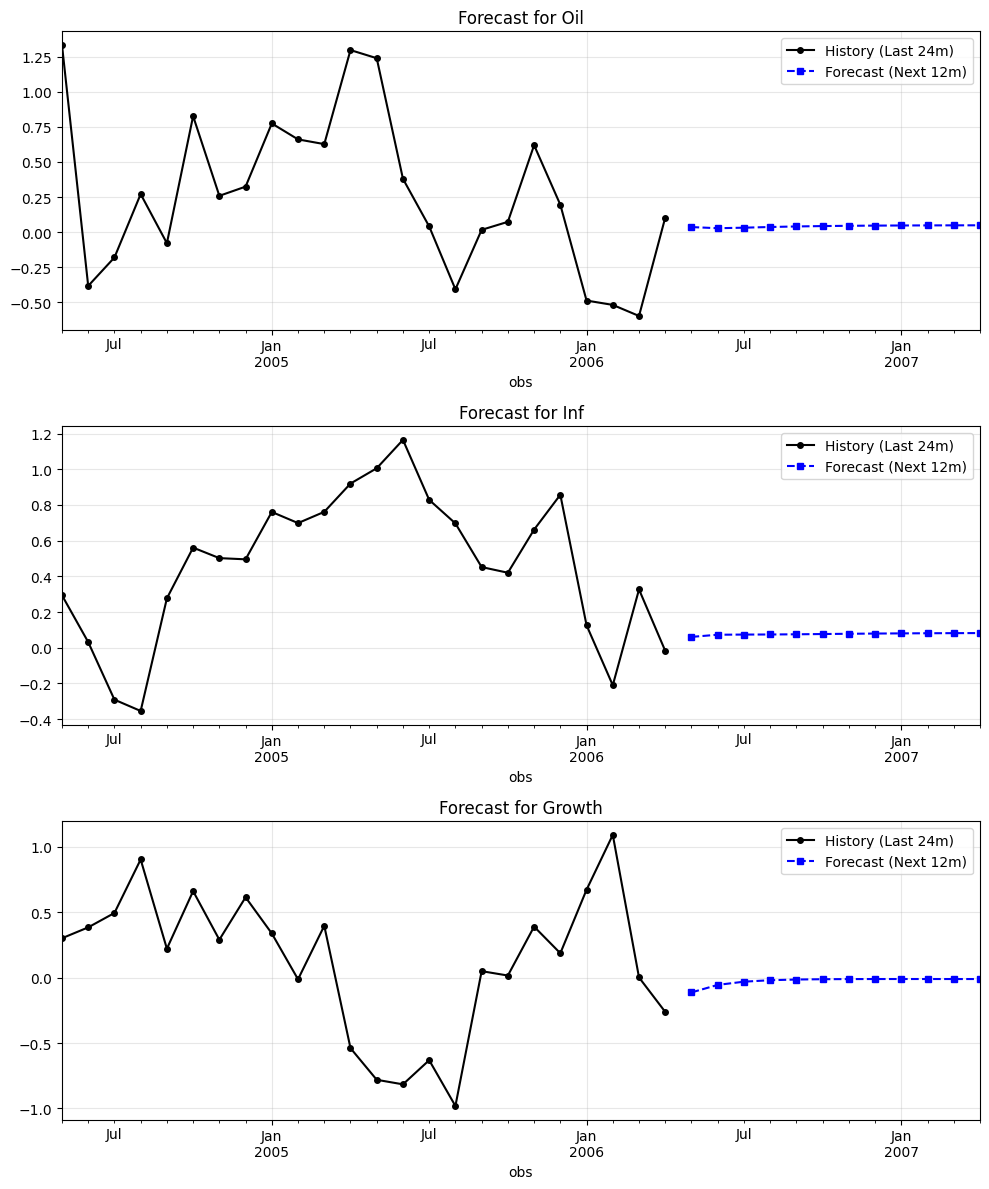

In [32]:
# =============================================================================
# 8. VAR FORECASTING (Dynamic h-step ahead) - CORRETTO
# =============================================================================
print("\n" + "="*60)
print("VAR FORECASTING (Dynamic h-step ahead)")
print("="*60)

# 1. Calcolo del forecast
n_forecast = 12
forecast_input = data.values[-best_p:]
fc = results.forecast(y=forecast_input, steps=n_forecast)

# 2. Creazione dell'indice futuro (Correzione dell'errore Timestamp)
last_date = data.index[-1]

# Se l'indice è una data (Timestamp), usiamo DateOffset per aggiungere mesi
if isinstance(last_date, pd.Timestamp):
    start_date = last_date + pd.DateOffset(months=1)
    # Generiamo un range di date mensili
    forecast_index = pd.date_range(start=start_date, periods=n_forecast, freq='MS')
else:
    # Se fosse già un PeriodIndex, l'addizione intera funzionerebbe, ma per sicurezza:
    start_date = last_date + 1
    forecast_index = pd.period_range(start=start_date, periods=n_forecast, freq='M')

# 3. DataFrame Forecast
df_forecast = pd.DataFrame(fc, index=forecast_index, columns=data.columns)

print(f"Forecasts for the next {n_forecast} months:")
print(df_forecast)

# =============================================================================
# 9. PLOT FORECASTS
# =============================================================================
print("\n--- Generating Forecast Plots ---")
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12))

for i, col in enumerate(data.columns):
    # Plot ultimi 24 mesi osservati
    data[col].tail(24).plot(ax=axes[i], label='History (Last 24m)', color='black', marker='o', markersize=4)
    # Plot forecast
    df_forecast[col].plot(ax=axes[i], label='Forecast (Next 12m)', color='blue', linestyle='--', marker='s', markersize=4)

    axes[i].set_title(f'Forecast for {col}', fontsize=12)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


GRANGER CAUSALITY ANALYSIS


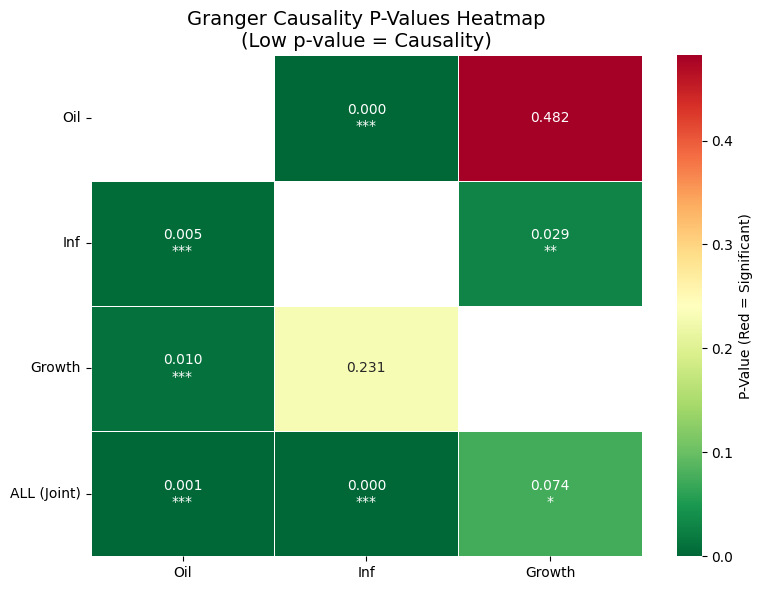


--- NARRATIVE SUMMARY OF CAUSALITY (p < 0.05) ---
✅ [EVIDENCE] Oil Granger-causes Inf (p=0.0000) ***
✅ [EVIDENCE] Inf Granger-causes Oil (p=0.0047) ***
✅ [EVIDENCE] Inf Granger-causes Growth (p=0.0287) **
✅ [EVIDENCE] Growth Granger-causes Oil (p=0.0098) ***

--- Generating Causality Network Graph ---


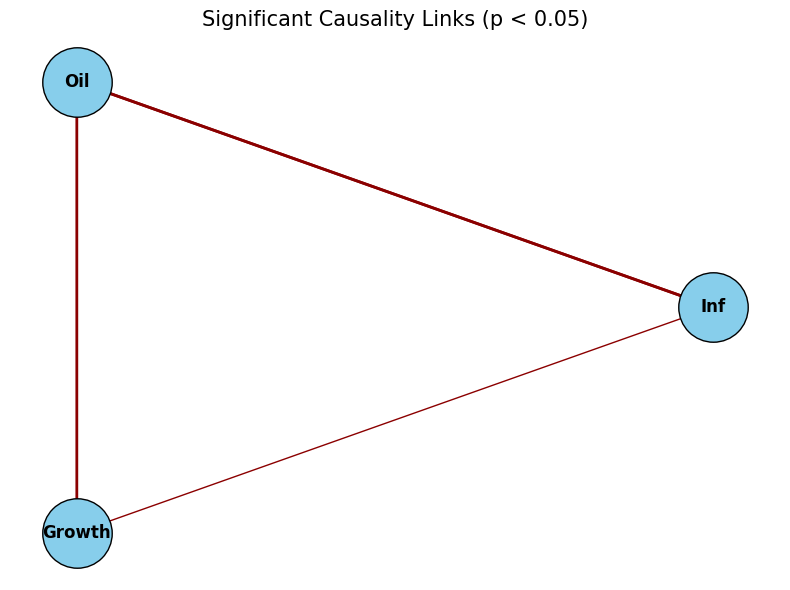

In [33]:
import seaborn as sns
import networkx as nx

# =============================================================================
# 10. GRANGER CAUSALITY TESTS (ENHANCED OUTPUT)
# =============================================================================
print("\n" + "="*60)
print("GRANGER CAUSALITY ANALYSIS")
print("="*60)

vars_list = data.columns
gc_pvalues = pd.DataFrame(np.nan, index=vars_list, columns=vars_list)

# 1. Calcolo P-Values
for target in vars_list:
    for source in vars_list:
        if target != source:
            test_result = results.test_causality(target, source, kind='f')
            gc_pvalues.loc[source, target] = test_result.pvalue

# Calcolo "All" (Joint test)
all_pvalues = {}
for target in vars_list:
    others = [v for v in vars_list if v != target]
    test_result = results.test_causality(target, others, kind='f')
    all_pvalues[target] = test_result.pvalue

# Aggiunta riga ALL
gc_pvalues.loc['ALL (Joint)', :] = pd.Series(all_pvalues)

# --- 2. VISUALIZZAZIONE 1: HEATMAP (Molto più chiara della tabella testuale) ---
plt.figure(figsize=(8, 6))
# Creiamo annotazioni con stelle di significatività
annot_labels = gc_pvalues.map(lambda x: f"{x:.3f}\n***" if x < 0.01 else (f"{x:.3f}\n**" if x < 0.05 else (f"{x:.3f}\n*" if x < 0.1 else f"{x:.3f}")))
# Maschera per nascondere i valori NaN (diagonale)
mask = gc_pvalues.isnull()

sns.heatmap(gc_pvalues, annot=annot_labels, fmt='', cmap='RdYlGn_r',
            mask=mask, linewidths=.5, cbar_kws={'label': 'P-Value (Red = Significant)'})

plt.title("Granger Causality P-Values Heatmap\n(Low p-value = Causality)", fontsize=14)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 3. VISUALIZZAZIONE 2: REPORT NARRATIVO (Testo chiaro) ---
print("\n--- NARRATIVE SUMMARY OF CAUSALITY (p < 0.05) ---")
found_causality = False
for source in vars_list:
    for target in vars_list:
        if source != target:
            pval = gc_pvalues.loc[source, target]
            if pval < 0.05:
                found_causality = True
                strength = "***" if pval < 0.01 else "**"
                print(f"✅ [EVIDENCE] {source} Granger-causes {target} (p={pval:.4f}) {strength}")
            # Decommenta se vuoi vedere anche le NON causalità
            # else:
            #     print(f"❌ [NO EVIDENCE] {source} does NOT cause {target} (p={pval:.4f})")

if not found_causality:
    print("No Granger Causality relationships found at 5% level.")

# --- 4. VISUALIZZAZIONE 3: NETWORK GRAPH (Grafo delle relazioni) ---
G = nx.DiGraph()
significant_level = 0.05

for target in vars_list:
    for source in vars_list:
        if target != source:
            pval = gc_pvalues.loc[source, target]
            if pval < significant_level:
                # Spessore freccia basato sulla significatività
                weight = 2 if pval < 0.01 else 1
                G.add_edge(source, target, weight=weight)

print("\n--- Generating Causality Network Graph ---")
plt.figure(figsize=(8, 6))
pos = nx.circular_layout(G)

# Disegno nodi
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Disegno archi (frecce)
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=25, edge_color='darkred', width=weights)

plt.title(f"Significant Causality Links (p < {significant_level})", fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()